## Step 1: Setup and Load Data

In this step, we import required libraries and load the saved copula parameters and stock return data.
We then extract the top stock pair based on the highest t-Copula correlation (ρ).
This pair will be used to build and backtest our copula-based trading strategy.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata, t

# Load copula parameters (calculated earlier)
copula_df = pd.read_csv("t_copula_params.csv")

# Sort by t-Copula correlation and select the top pair
top_pair = copula_df.sort_values("t-Copula ρ", ascending=False).iloc[0]
stock_x = top_pair["Stock A"]
stock_y = top_pair["Stock B"]
rho_hat = top_pair["t-Copula ρ"]
df_hat = top_pair["t-Copula ν"]

print(f"Top pair: {stock_x} & {stock_y}")
print(f"ρ = {rho_hat:.4f}, ν = {df_hat:.2f}")

Top pair: DHI & LEN
ρ = 0.9367, ν = 5.00


## Step 2: Load Price Data and Compute Log Returns

We load historical adjusted closing prices for the S&P 500 stocks and compute daily log returns for the selected pair.
We then apply an ECDF transformation to prepare the data for copula-based modeling.

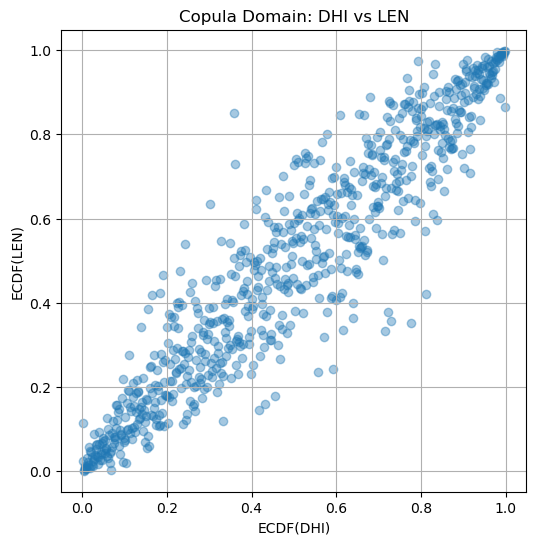

In [6]:
# Load historical adjusted close prices
price_df = pd.read_csv("sp500_prices_cleaned.csv", index_col=0, parse_dates=True)

# Extract price series for the selected pair
pair_prices = price_df[[stock_x, stock_y]].dropna()

# Compute log returns
log_returns = np.log(pair_prices / pair_prices.shift(1)).dropna()

# ECDF transform function
def ecdf_transform(series):
    ranks = rankdata(series)
    return ranks / (len(series) + 1)

# Apply ECDF transformation
u = ecdf_transform(log_returns[stock_x])
v = ecdf_transform(log_returns[stock_y])

# Visualize copula domain
plt.figure(figsize=(6, 6))
plt.scatter(u, v, alpha=0.4)
plt.xlabel(f"ECDF({stock_x})")
plt.ylabel(f"ECDF({stock_y})")
plt.title(f"Copula Domain: {stock_x} vs {stock_y}")
plt.grid(True)
plt.show()

## Step 3: Simulate from Fitted t-Copula and Define Signal Thresholds

We simulate a large number of (u, v) pairs from the fitted t-Copula using our previously estimated parameters (ρ and ν).
This simulated copula cloud is used to estimate joint tail probabilities, allowing us to define statistically meaningful long/short signal thresholds.

In [13]:
from scipy.stats import t as student_t
from scipy.stats import norm
from scipy.stats import multivariate_t

# Number of samples to simulate from copula
N = 10000

# Step 1: Create correlated t-distributed variables
cov = np.array([[1, rho_hat], [rho_hat, 1]])
mean = np.zeros(2)
raw_t_samples = np.random.multivariate_normal(mean, cov, size=N)
t_copula_samples = multivariate_t.rvs(loc=mean, shape=cov, df=df_hat, size=N)

# Step 2: Transform to uniform margins
u_sim = student_t.cdf(t_copula_samples[:, 0], df=df_hat)
v_sim = student_t.cdf(t_copula_samples[:, 1], df=df_hat)

# Step 3: Define thresholds
lower_bound = 0.05
upper_bound = 0.95

u_lower, u_upper = np.quantile(u_sim, [lower_bound, upper_bound])
v_lower, v_upper = np.quantile(v_sim, [lower_bound, upper_bound])

print(f"✅ u thresholds: {u_lower:.4f} – {u_upper:.4f}")
print(f"✅ v thresholds: {v_lower:.4f} – {v_upper:.4f}")

✅ u thresholds: 0.0508 – 0.9510
✅ v thresholds: 0.0521 – 0.9510


### Step 4: Generate Trading Signals from Historical Data

We use the previously estimated t-Copula thresholds to generate trading signals. For each day, we map the log returns to ECDF space and check whether they fall into the copula's extreme tails. These tail events are interpreted as trading signals.

In [16]:
# Re-use ECDF transform function
def ecdf_transform(series):
    ranks = series.rank(method="first")
    return ranks / (len(series) + 1)

# Prepare ECDF-transformed data
u_hist = ecdf_transform(log_returns["DHI"].dropna())
v_hist = ecdf_transform(log_returns["LEN"].dropna())
common_index = u_hist.index.intersection(v_hist.index)
u_hist = u_hist.loc[common_index]
v_hist = v_hist.loc[common_index]

# Generate signals
signals = []
for u_val, v_val in zip(u_hist, v_hist):
    if u_val < u_lower or v_val < v_lower:
        signals.append(1)  # Long DHI, Short LEN
    elif u_val > u_upper or v_val > v_upper:
        signals.append(-1)  # Short DHI, Long LEN
    else:
        signals.append(0)  # No trade

# Create signal DataFrame
signal_df = pd.DataFrame({
    "DHI": log_returns["DHI"].loc[common_index],
    "LEN": log_returns["LEN"].loc[common_index],
    "Signal": signals
})

display(signal_df.head(10))

,DHI,LEN,Signal
Date,,,
2022-01-04 00:00:00-05:00,0.004361,0.006508,0
2022-01-05 00:00:00-05:00,-0.025386,-0.015492,0
2022-01-06 00:00:00-05:00,-0.015350,-0.025038,0
2022-01-07 00:00:00-05:00,-0.063659,-0.048536,1
2022-01-10 00:00:00-05:00,0.005027,0.010436,0
2022-01-11 00:00:00-05:00,0.030962,0.034949,-1
2022-01-12 00:00:00-05:00,0.007065,0.001947,0
2022-01-13 00:00:00-05:00,0.003313,0.005543,0
2022-01-14 00:00:00-05:00,-0.012406,-0.003507,0


### Step 5: Apply Signals and Compute Strategy Returns

We apply the generated signals to compute the strategy's daily returns. The signal at time *t-1* is used to decide the position for time *t*. The return is computed as the spread return between the two assets, adjusted by the signal direction.

In [19]:
# Shift signal to avoid lookahead bias
signal_df["Lagged Signal"] = signal_df["Signal"].shift(1)

# Calculate daily spread return: Long A / Short B means A - B
signal_df["Spread Return"] = signal_df["DHI"] - signal_df["LEN"]

# Strategy return = signal * spread return
signal_df["Strategy Return"] = signal_df["Lagged Signal"] * signal_df["Spread Return"]

# Drop NaN introduced by shift
signal_df.dropna(inplace=True)

# Cumulative return
signal_df["Cumulative Return"] = (1 + signal_df["Strategy Return"]).cumprod()

display(signal_df[["Lagged Signal", "Spread Return", "Strategy Return", "Cumulative Return"]].head(10))

,Lagged Signal,Spread Return,Strategy Return,Cumulative Return
Date,,,,
2022-01-05 00:00:00-05:00,0.0,-0.009894,-0.000000,1.000000
2022-01-06 00:00:00-05:00,0.0,0.009688,0.000000,1.000000
2022-01-07 00:00:00-05:00,0.0,-0.015123,-0.000000,1.000000
2022-01-10 00:00:00-05:00,1.0,-0.005408,-0.005408,0.994592
2022-01-11 00:00:00-05:00,0.0,-0.003987,-0.000000,0.994592
2022-01-12 00:00:00-05:00,-1.0,0.005117,-0.005117,0.989502
2022-01-13 00:00:00-05:00,0.0,-0.002230,-0.000000,0.989502
2022-01-14 00:00:00-05:00,0.0,-0.008899,-0.000000,0.989502
2022-01-18 00:00:00-05:00,0.0,0.012270,0.000000,0.989502


### Step 6: Visualize Strategy Performance

We plot the cumulative return of the strategy over time to evaluate its profitability and trading signal effectiveness.

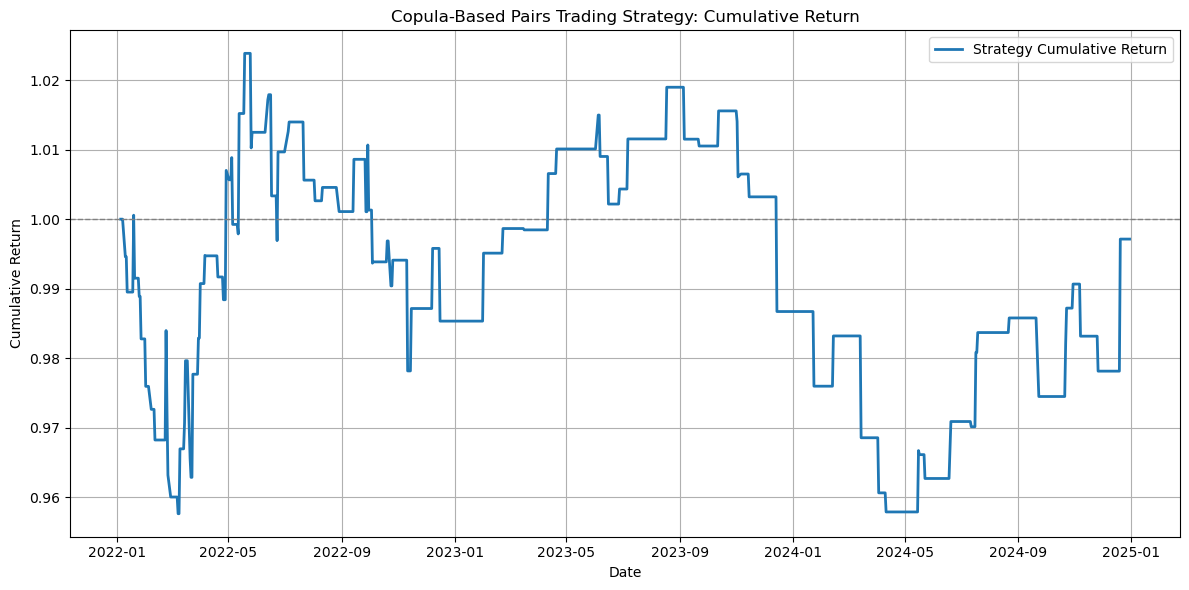

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(signal_df.index, signal_df["Cumulative Return"], label="Strategy Cumulative Return", linewidth=2)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title("Copula-Based Pairs Trading Strategy: Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 7: Evaluate Strategy Performance

We calculate key performance metrics for the copula-based trading strategy, including Sharpe Ratio, Win Rate, and Max Drawdown. These metrics provide insight into the risk-adjusted returns and consistency of the strategy.

In [25]:
import numpy as np

# Daily returns
daily_returns = signal_df["Strategy Return"]

# Sharpe Ratio (assumes 252 trading days)
sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()

# Win rate
win_rate = (daily_returns > 0).sum() / len(daily_returns)

# Max Drawdown
cum_returns = signal_df["Cumulative Return"]
roll_max = cum_returns.cummax()
drawdown = (cum_returns - roll_max) / roll_max
max_drawdown = drawdown.min()

# Output
print(f"📈 Sharpe Ratio: {sharpe_ratio:.3f}")
print(f"✅ Win Rate: {win_rate:.2%}")
print(f"🔻 Max Drawdown: {max_drawdown:.2%}")

📈 Sharpe Ratio: 0.003
✅ Win Rate: 6.27%
🔻 Max Drawdown: -6.45%


### Final Step: Export Strategy Results

We save the signal dataframe with daily positions and returns to a CSV file. This can be used for backtesting across different pairs or for ensemble trading strategies.

In [28]:
# Save results to CSV
signal_df.to_csv("copula_strategy_DHI_LEN.csv")
print("✅ Results exported to 'copula_strategy_DHI_LEN.csv'")

✅ Results exported to 'copula_strategy_DHI_LEN.csv'
